STUDENT STRESS DETECTION SYSTEM

[1] Loading dataset...
Dataset loaded successfully.
Number of rows    : 500
Number of columns : 11

[2] DATASET PREVIEW
  student_id  sleep_hours  study_hours_per_day  heart_rate_bpm  \
0    STU_001          7.2                  8.3              78   
1    STU_002          6.3                 10.8              68   
2    STU_003          7.5                  2.5              83   
3    STU_004          8.8                  7.4              69   
4    STU_005          6.1                  4.4              77   

   academic_workload  caffeine_intake_mg  physical_activity_min  \
0                  7               373.0                   29.0   
1                  1               442.0                   61.0   
2                  8               137.0                   48.0   
3                  3               334.0                   65.0   
4                  6               246.0                   71.0   

   social_interaction_hrs   gpa  perceived_cont

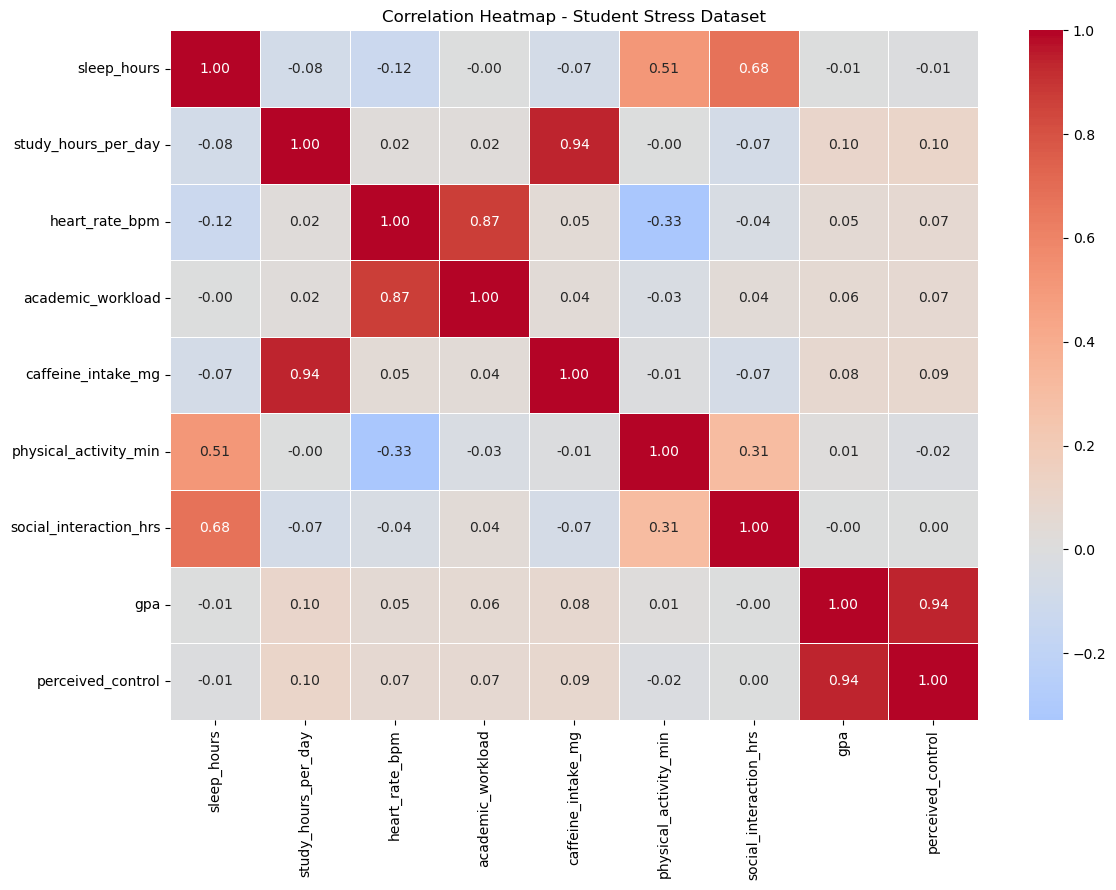

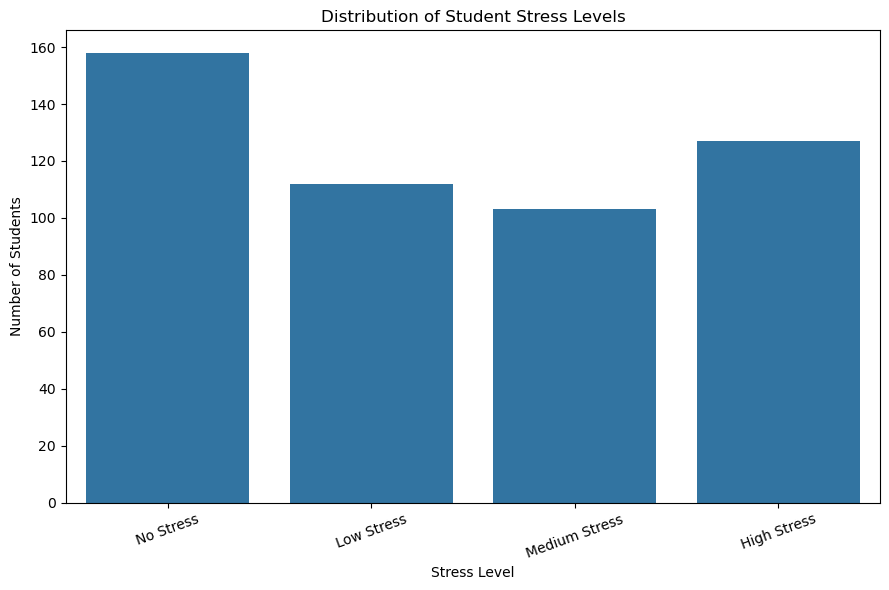

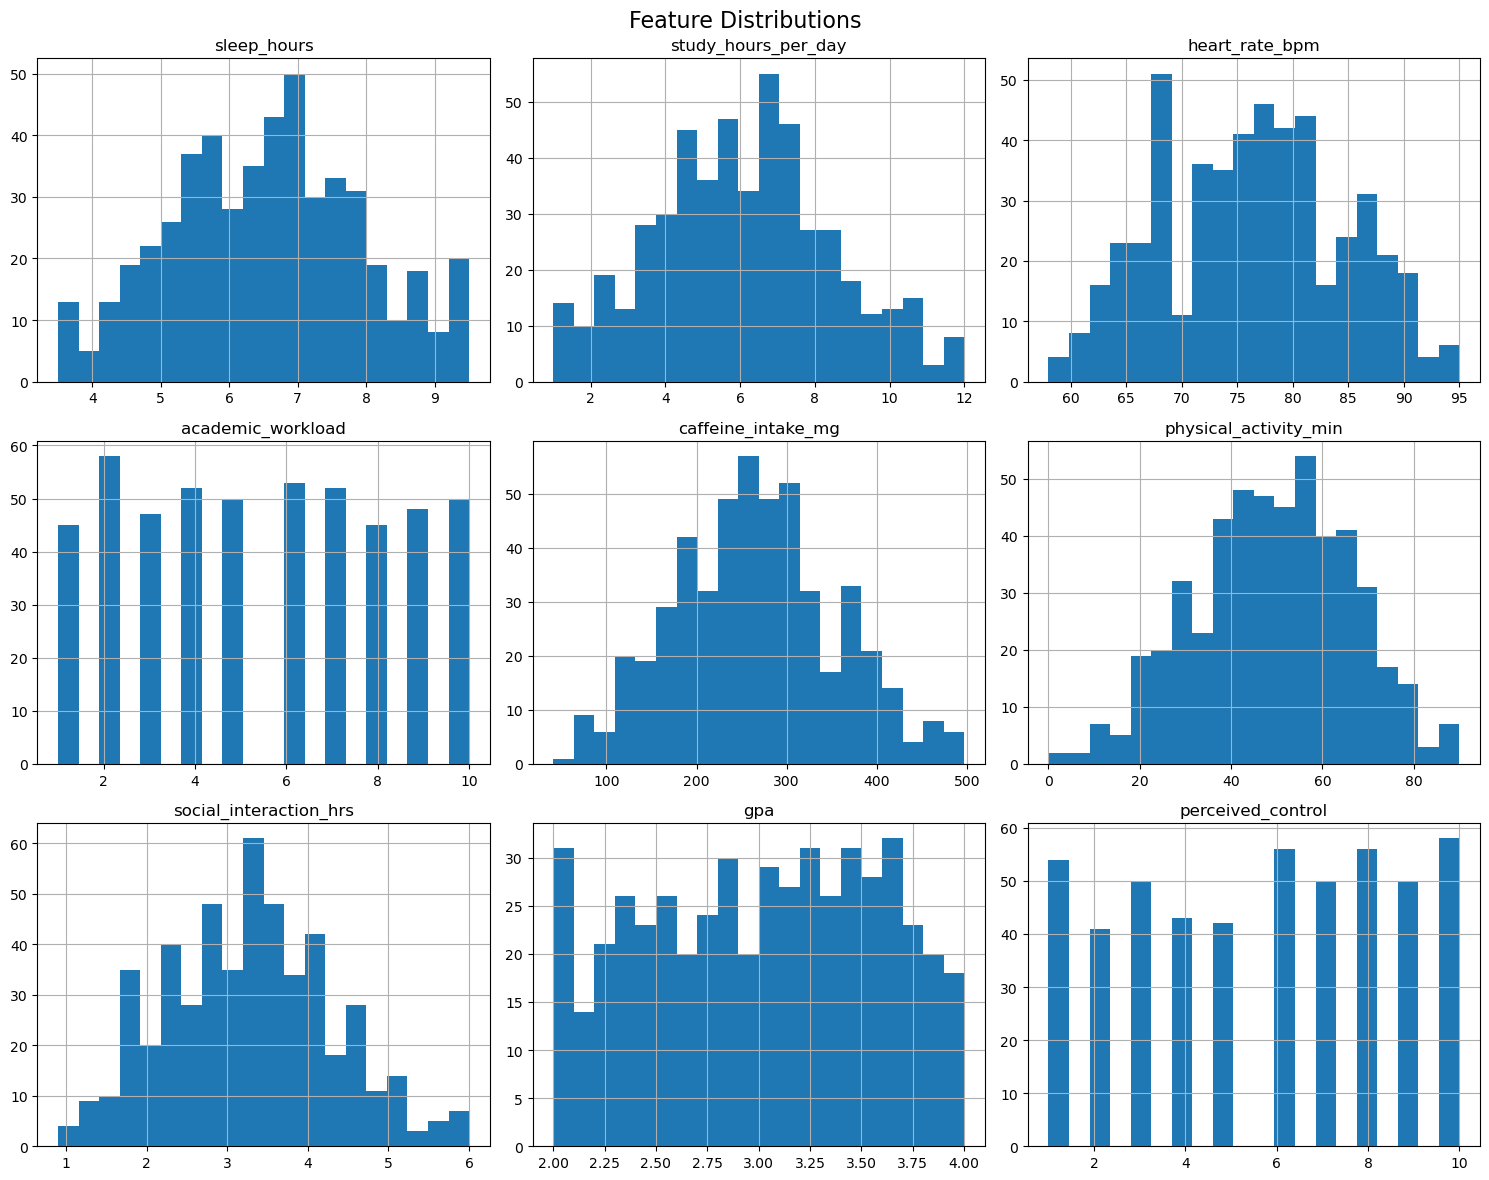

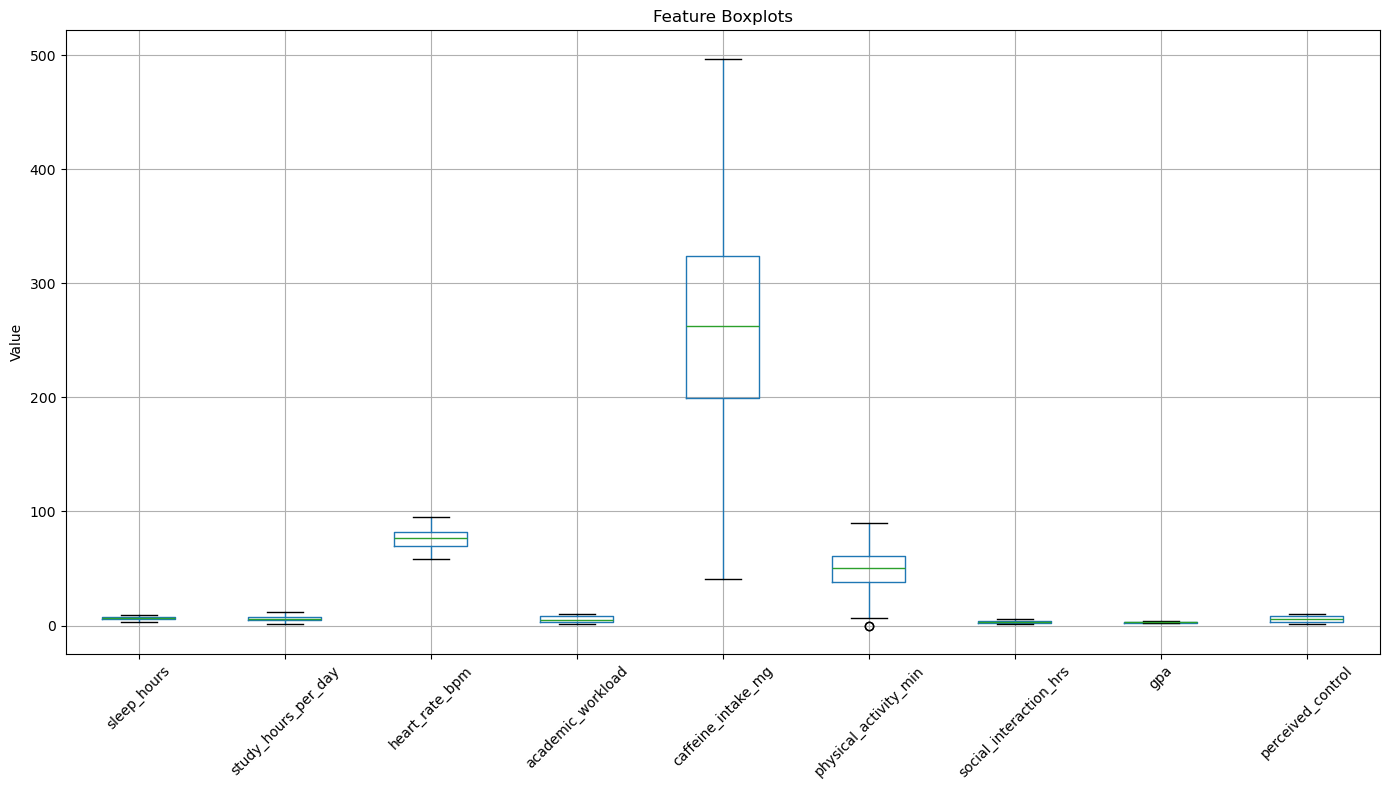


[16] TRAIN-TEST SPLIT
Training samples: 400
Testing samples : 100

[17] BUILDING RANDOM FOREST MODEL

Training model...
Model training completed.

[18] MODEL PERFORMANCE
Accuracy : 0.7400
Precision: 0.7374
Recall   : 0.7400
F1 Score : 0.7382

[19] CLASSIFICATION REPORT
               precision    recall  f1-score   support

  High Stress       0.85      0.92      0.88        25
   Low Stress       0.59      0.59      0.59        22
Medium Stress       0.60      0.57      0.59        21
    No Stress       0.84      0.81      0.83        32

     accuracy                           0.74       100
    macro avg       0.72      0.72      0.72       100
 weighted avg       0.74      0.74      0.74       100


[20] CONFUSION MATRIX
[[26  5  1  0]
 [ 4 13  5  0]
 [ 1  4 12  4]
 [ 0  0  2 23]]


<Figure size 800x600 with 0 Axes>

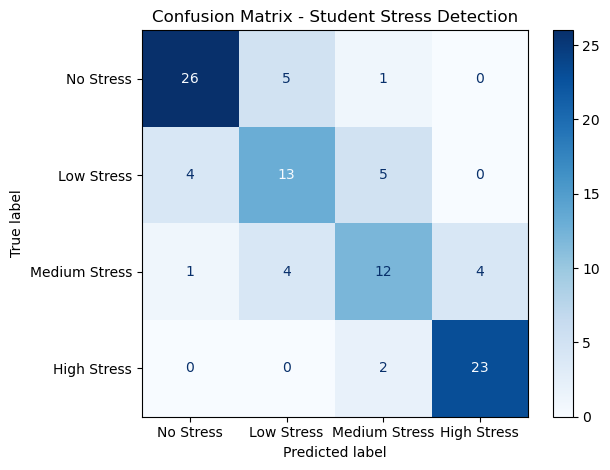


[21] 5-FOLD CROSS VALIDATION
Cross-validation scores:
Fold 1: 0.7500
Fold 2: 0.6500
Fold 3: 0.6300
Fold 4: 0.7200
Fold 5: 0.7400

Mean CV Accuracy: 0.6980
CV Std Dev     : 0.0487

[22] FEATURE IMPORTANCE
heart_rate_bpm            0.138568
academic_workload         0.134797
gpa                       0.126384
study_hours_per_day       0.124564
sleep_hours               0.108105
caffeine_intake_mg        0.107717
perceived_control         0.093891
social_interaction_hrs    0.089503
physical_activity_min     0.076472
dtype: float64


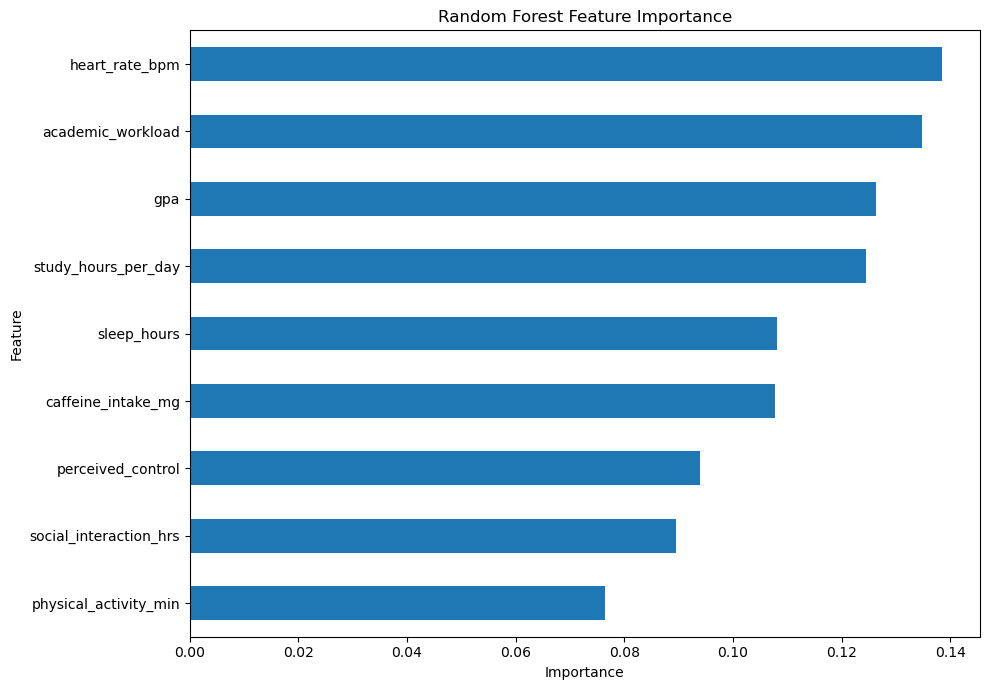


[23] MODEL SAVED
Saved model: student_stress_model.pkl

[24] SAMPLE STUDENT PREDICTION
Predicted Stress Level: High Stress

Class probabilities:
High Stress: 59.00%
Low Stress: 8.00%
Medium Stress: 32.33%
No Stress: 0.67%

TRAINING AND EVALUATION COMPLETED


In [ ]:
# ============================================================
# STUDENT STRESS DETECTION SYSTEM
# Machine Learning Training & Evaluation
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import 
(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

import pandas as pd

DATA_PATH = r"C:\Users\Rizwan computers\Documents\student_stress_dataset_500.csv"

print("=" * 70)
print("STUDENT STRESS DETECTION SYSTEM")
print("=" * 70)

print("\n[1] Loading dataset...")

df = pd.read_csv(DATA_PATH)


print("Dataset loaded successfully.")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


# ------------------------------------------------------------
# 3. BASIC DATASET DESCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[2] DATASET PREVIEW")
print("=" * 70)

print(df.head())


print("\n" + "=" * 70)
print("[3] DATASET SHAPE")
print("=" * 70)

print(df.shape)


print("\n" + "=" * 70)
print("[4] COLUMN NAMES")
print("=" * 70)

print(df.columns.tolist())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[5] DATASET INFORMATION")
print("=" * 70)

df.info()


# ------------------------------------------------------------
# 5. STATISTICAL DESCRIPTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[6] STATISTICAL DESCRIPTION")
print("=" * 70)

print(df.describe())


# ------------------------------------------------------------
# 6. CHECK DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[7] DATA TYPES")
print("=" * 70)

print(df.dtypes)


# ------------------------------------------------------------
# 7. CHECK NULL VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[8] NULL VALUE CHECK")
print("=" * 70)

null_values = df.isnull().sum()

print(null_values)

if null_values.sum() == 0:
    print("\nNo missing/null values found.")
else:
    print("\nMissing values found.")


# ------------------------------------------------------------
# 8. CHECK DUPLICATES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[9] DUPLICATE CHECK")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")


# ------------------------------------------------------------
# 9. CHECK UNIQUE STUDENT IDs
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[10] IDENTIFIER CHECK")
print("=" * 70)

print(f"Total Student IDs : {df['student_id'].count()}")
print(f"Unique Student IDs: {df['student_id'].nunique()}")


# ------------------------------------------------------------
# 10. TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[11] TARGET DISTRIBUTION")
print("=" * 70)

print(df["stress_level"].value_counts())
print("\nPercentage:")
print(df["stress_level"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 11. CHECK NUMERIC RANGES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[12] NUMERIC FEATURE RANGES")
print("=" * 70)

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column:30s} "
        f"Min = {df[column].min():.2f} | "
        f"Max = {df[column].max():.2f}"
    )


# ------------------------------------------------------------
# 12. REMOVE IDENTIFIER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[13] REMOVING IDENTIFIER")
print("=" * 70)

# Student ID is not a meaningful ML feature.
df_model = df.drop(columns=["student_id"])

print("student_id removed.")
print("Remaining columns:")
print(df_model.columns.tolist())


# ------------------------------------------------------------
# 13. CHECK WHETHER ENCODING IS REQUIRED
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[14] ENCODING CHECK")
print("=" * 70)

X = df_model.drop(columns=["stress_level"])
y = df_model["stress_level"]

print("\nFeature data types:")
print(X.dtypes)

print("\nTarget data type:")
print(y.dtype)

print(
    "\nAll predictor variables are numerical, "
    "so categorical feature encoding is not required."
)

print(
    "The target contains class names such as "
    "'Low Stress' and 'High Stress'. "
    "Random Forest can handle these labels directly."
)


# ------------------------------------------------------------
# 14. CORRELATION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[15] CORRELATION MATRIX")
print("=" * 70)

correlation_matrix = df_model.corr(numeric_only=True)

print(correlation_matrix.round(2))


# ------------------------------------------------------------
# 15. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Student Stress Dataset")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 16. TARGET DISTRIBUTION VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="stress_level",
    order=[
        "No Stress",
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ]
)

plt.title("Distribution of Student Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "stress_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 17. FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

df_model.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Feature Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 18. BOXPLOTS FOR NUMERIC FEATURES
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

df_model.drop(
    columns=["stress_level"]
).boxplot(rot=45)

plt.title("Feature Boxplots")
plt.ylabel("Value")

plt.tight_layout()

plt.savefig(
    "feature_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 19. TRAIN-TEST SPLIT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[16] TRAIN-TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


# ------------------------------------------------------------
# 20. BUILD MACHINE LEARNING PIPELINE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[17] BUILDING RANDOM FOREST MODEL")
print("=" * 70)

model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)


# ------------------------------------------------------------
# 21. TRAIN MODEL
# ------------------------------------------------------------

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed.")


# ------------------------------------------------------------
# 22. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 23. MODEL EVALUATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[18] MODEL PERFORMANCE")
print("=" * 70)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ------------------------------------------------------------
# 24. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[19] CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 25. CONFUSION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[20] CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[
        "No Stress",
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ]
)

print(cm)


# ------------------------------------------------------------
# 26. CONFUSION MATRIX VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Stress",
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Student Stress Detection")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 27. CROSS-VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[21] 5-FOLD CROSS VALIDATION")
print("=" * 70)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Std Dev     : {cv_scores.std():.4f}")


# ------------------------------------------------------------
# 28. FEATURE IMPORTANCE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[22] FEATURE IMPORTANCE")
print("=" * 70)

rf_classifier = model.named_steps["classifier"]

feature_importance = pd.Series(
    rf_classifier.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print(feature_importance)


# ------------------------------------------------------------
# 29. FEATURE IMPORTANCE VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 30. SAVE TRAINED MODEL
# ------------------------------------------------------------

MODEL_PATH = "student_stress_model.pkl"

joblib.dump(
    model,
    MODEL_PATH
)

print("\n" + "=" * 70)
print("[23] MODEL SAVED")
print("=" * 70)

print(f"Saved model: {MODEL_PATH}")


# ------------------------------------------------------------
# 31. SIMPLE PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_student_stress(
    sleep_hours,
    study_hours_per_day,
    heart_rate_bpm,
    academic_workload,
    caffeine_intake_mg,
    physical_activity_min,
    social_interaction_hrs,
    gpa,
    perceived_control
):
    """
    Predict the stress level of a student.

    Returns:
        Predicted stress class.
    """

    input_data = pd.DataFrame(
        [[
            sleep_hours,
            study_hours_per_day,
            heart_rate_bpm,
            academic_workload,
            caffeine_intake_mg,
            physical_activity_min,
            social_interaction_hrs,
            gpa,
            perceived_control
        ]],
        columns=X.columns
    )

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0]

    class_probabilities = dict(
        zip(
            model.classes_,
            probability
        )
    )

    return prediction, class_probabilities


# ------------------------------------------------------------
# 32. TEST THE INPUT FUNCTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[24] SAMPLE STUDENT PREDICTION")
print("=" * 70)

sample_prediction, sample_probability = predict_student_stress(
    sleep_hours=6.0,
    study_hours_per_day=7.0,
    heart_rate_bpm=80,
    academic_workload=7,
    caffeine_intake_mg=250,
    physical_activity_min=30,
    social_interaction_hrs=2.0,
    gpa=3.0,
    perceived_control=5
)

print(f"Predicted Stress Level: {sample_prediction}")

print("\nClass probabilities:")

for class_name, probability in sample_probability.items():
    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )


print("\n" + "=" * 70)
print("TRAINING AND EVALUATION COMPLETED")
print("=" * 70)